# ARTI 403 Image Processing
## Lab 5: Spatial Filtering, Smoothing and Sharpening

Name: Mohammed Saeed Alamodi
ID: 2240009007

The parrot image wasnt included with the lab so I used the astronaut image from skimage for the unsharp masking. For the assessment I used the coffee and cameraman images.

## Task 1: Unsharp Masking

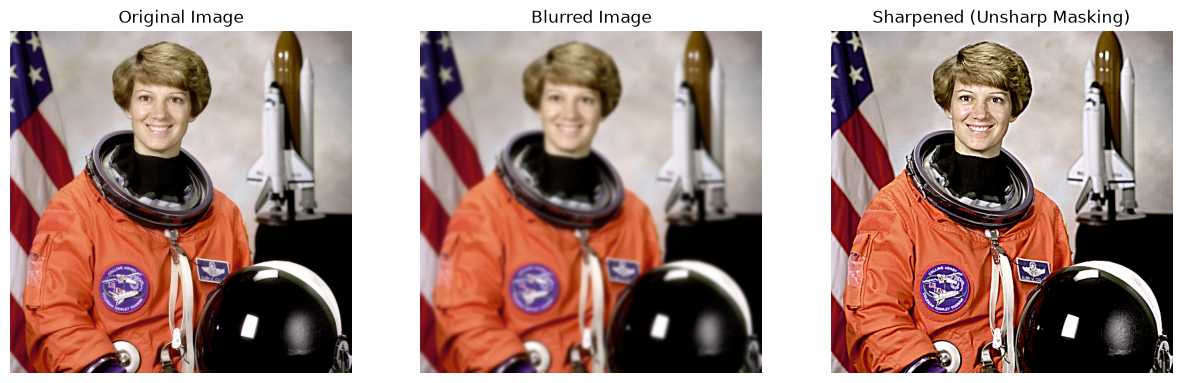

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the image
image = cv2.imread('images/astronaut.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB

# Gaussian sigma
sigma = 2
# parameter
amount = 1.5

# Convert image to float32 for processing
image_float = image.astype(np.float32) / 255.0

# Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

# Perform Unsharp Masking
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

# Plot original, blurred, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(blurred)
ax[1].set_title("Blurred Image")
ax[1].axis("off")
ax[2].imshow(sharpened)
ax[2].set_title("Sharpened (Unsharp Masking)")
ax[2].axis("off")
plt.show()

The sharpened image has clearer edges than the original, you can see it in the face, hair and the patches on the suit. Because amount is 1.5 the effect is strong and some edges like the helmet have a light halo around them.

# Assessment

## Task 1
Convolve an image with a 7x7 box filter

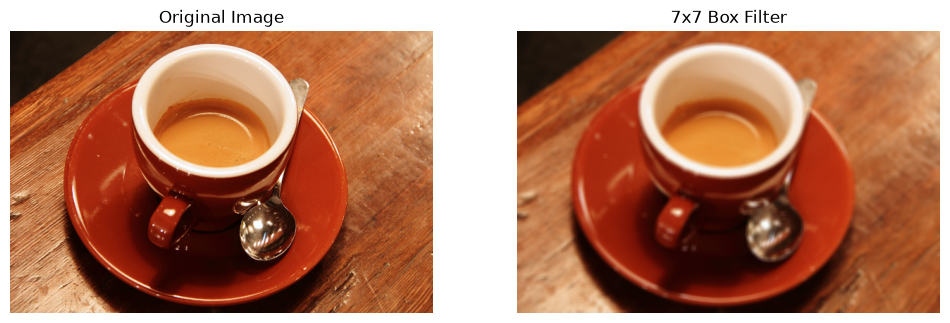

In [2]:
img = cv2.imread('images/coffee.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

kernel = np.ones((7, 7), np.float32) / 49
box = cv2.filter2D(img, -1, kernel)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(img)
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(box)
ax[1].set_title("7x7 Box Filter")
ax[1].axis("off")
plt.show()

The box filter takes the average of the 7x7 neighborhood for every pixel so the image becomes blurry. The lines in the wood and the small scratches are mostly gone and the edges of the cup are softer.

## Task 2
Apply a 5x5 Gaussian filter and then a 21x21 Gaussian filter

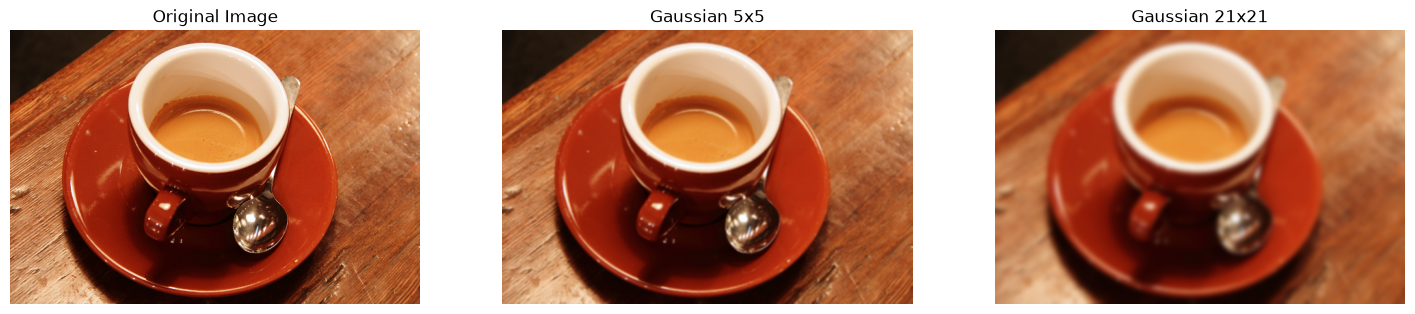

In [3]:
gauss5 = cv2.GaussianBlur(img, (5, 5), 0)
gauss21 = cv2.GaussianBlur(img, (21, 21), 0)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].imshow(img)
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(gauss5)
ax[1].set_title("Gaussian 5x5")
ax[1].axis("off")
ax[2].imshow(gauss21)
ax[2].set_title("Gaussian 21x21")
ax[2].axis("off")
plt.show()

The 5x5 filter only blurs the image a little and it looks close to the original. The 21x21 one is much more blurry and most of the details are gone, but the shape of the cup and the spoon can still be seen. So a bigger kernel gives more blur.

## Task 3
Sharpen an image using a 3x3 Laplacian filter. I used ksize=1 since in opencv this is the 3x3 kernel [[0,1,0],[1,-4,1],[0,1,0]].

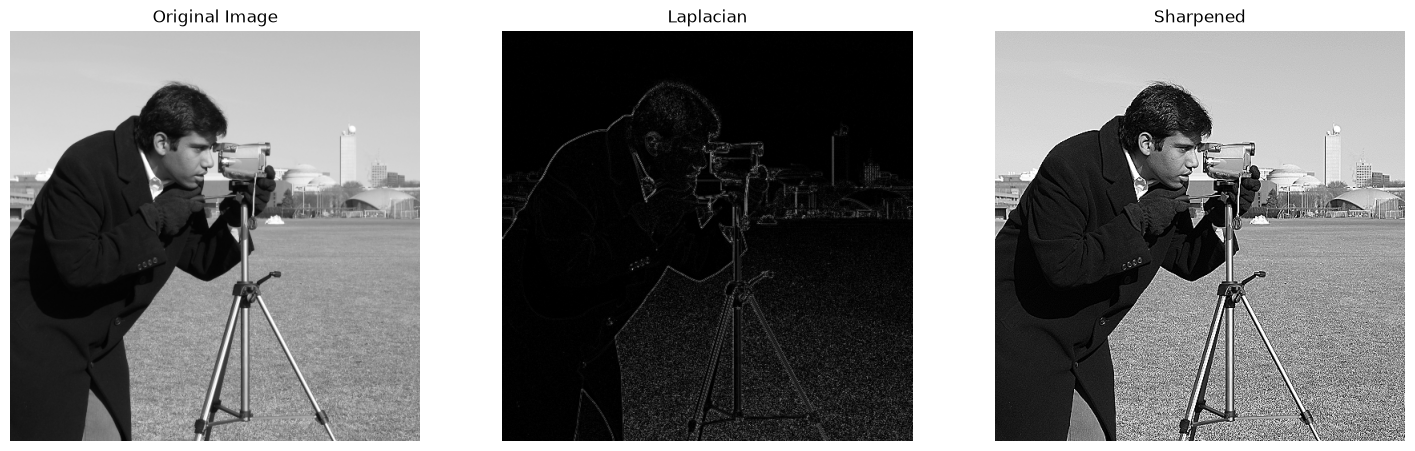

In [4]:
# read the image
gray = cv2.imread('images/cameraman.png', cv2.IMREAD_GRAYSCALE)

# convert to float32
image_float = gray.astype(np.float32) / 255.0

# laplacian
laplacian = cv2.Laplacian(image_float, cv2.CV_32F, ksize=1)

# sharpen
sharpened = np.clip(image_float - laplacian, 0, 1)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(image_float, cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(np.abs(laplacian), cmap='gray')
ax[1].set_title("Laplacian")
ax[1].axis("off")
ax[2].imshow(sharpened, cmap='gray')
ax[2].set_title("Sharpened")
ax[2].axis("off")
plt.show()

The laplacian result is mostly black and only shows the edges like the outline of the man, the tripod and the buildings (I showed the absolute value because it has negative values). After subtracting it from the original the image looks sharper, but the grass also got more noisy.